<a href="https://colab.research.google.com/github/David010101-biner/Data-Science-Portfolios/blob/main/Customer_Personality_%26_Behavior_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Customer Personality & Behavior Analysis
### *End-to-End Predictive Modeling & Data Segmentation*

**Author:** David Syahputra
**Domain:** Informatics & Business Management
**Core Focus:** Data Analytics, Machine Learning (Clustering & Classification), & Business Intelligence
        
**Executive Objective:**
Mengekstraksi *actionable insights* dari data perilaku pelanggan guna mengoptimalkan efisiensi strategi kampanye pemasaran dan meningkatkan *Return on Investment* (ROI) bagi perusahaan.
        
---

In [2]:
# 1. Import library yang dibutuhkan untuk komputasi dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 2. Mengatur tema visualisasi agar rapi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")

# 3. Menghubungkan Google Colab dengan Google Drive
drive.mount('/content/drive')

# 4. Mendefinisikan path dataset sesuai dengan lokasi terbaru di Drive
file_path = '/content/drive/MyDrive/projek google colab/portofolio 1/marketing_campaign.csv'

# 5. Membaca dataset (menggunakan separator tab '\t')
df = pd.read_csv(file_path, sep='\t')

# Menampilkan informasi awal dataset
print("=== Dimensi Dataset ===")
print(f"Jumlah Baris: {df.shape[0]}, Jumlah Kolom: {df.shape[1]}")
display(df.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Dimensi Dataset ===
Jumlah Baris: 2240, Jumlah Kolom: 29


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0


In [3]:
# 1. Pengecekan Missing Values di awal
print("Missing values sebelum dibersihkan:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Menghapus baris yang memiliki nilai kosong (pada dataset ini biasanya kolom Income)
df = df.dropna().reset_index(drop=True)

# 2. Feature Engineering (Membuat Fitur Baru)
# Menghitung umur pelanggan berdasarkan tahun ini (2026)
df['Age'] = 2026 - df['Year_Birth']

# Menjumlahkan semua pengeluaran produk menjadi satu metrik: 'Total_Spend'
df['Total_Spend'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + \
                    df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

# 3. Membersihkan Outliers (Pencilan)
# Menghapus data umur yang tidak wajar (misal: ada yang lahir tahun 1893)
df = df[df['Age'] < 90]

# Menghapus pelanggan dengan pendapatan ekstrem (misal > 200.000) agar model tidak bias
df = df[df['Income'] < 200000]

print("\n=== Data Setelah Dibersihkan ===")
print(f"Sisa Baris Data: {df.shape[0]}")
display(df[['Year_Birth', 'Age', 'Income', 'Total_Spend']].head())

Missing values sebelum dibersihkan:
Income    24
dtype: int64

=== Data Setelah Dibersihkan ===
Sisa Baris Data: 2212


,Year_Birth,Age,Income,Total_Spend
0,1957,69,58138.0,1617
1,1954,72,46344.0,27
2,1965,61,71613.0,776
3,1984,42,26646.0,53
4,1981,45,58293.0,422


Menghasilkan Visualisasi Data...


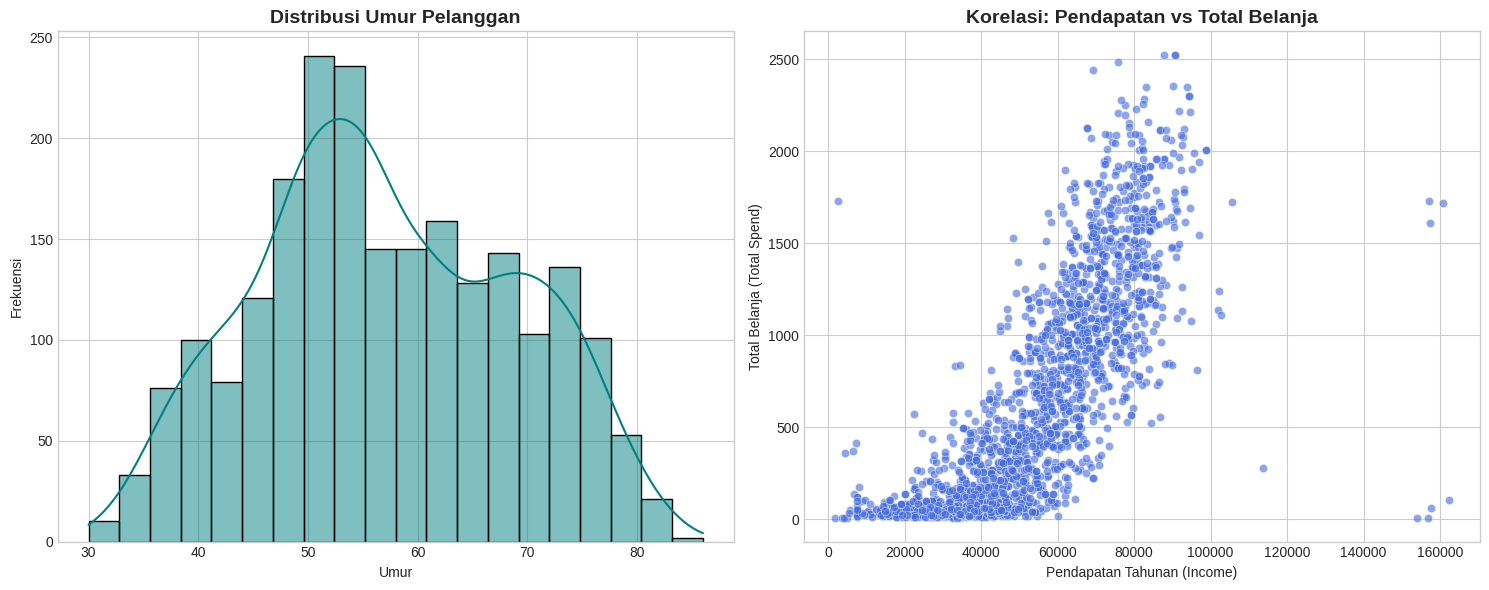

In [4]:
print("Menghasilkan Visualisasi Data...")

plt.figure(figsize=(15, 6))

# Grafik 1: Distribusi Umur Pelanggan
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], bins=20, kde=True, color='teal')
plt.title('Distribusi Umur Pelanggan', fontsize=14, fontweight='bold')
plt.xlabel('Umur')
plt.ylabel('Frekuensi')

# Grafik 2: Hubungan Pendapatan dan Total Belanja
plt.subplot(1, 2, 2)
sns.scatterplot(x='Income', y='Total_Spend', data=df, alpha=0.6, color='royalblue')
plt.title('Korelasi: Pendapatan vs Total Belanja', fontsize=14, fontweight='bold')
plt.xlabel('Pendapatan Tahunan (Income)')
plt.ylabel('Total Belanja (Total Spend)')

plt.tight_layout()
plt.show()

Menjalankan K-Means Clustering...


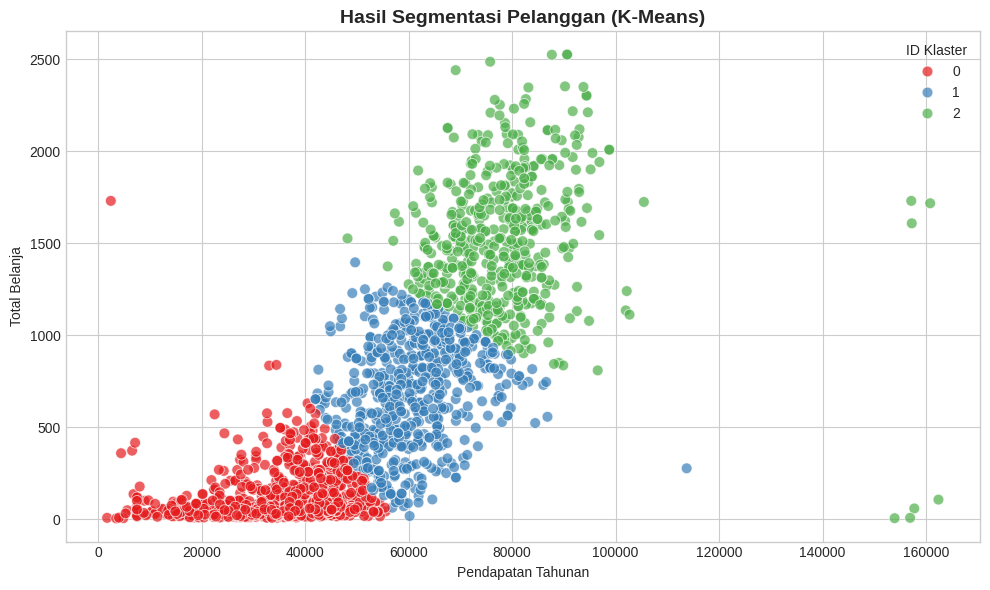

Analisis Singkat:
Algoritma berhasil membagi pelanggan menjadi 3 kelompok yang sangat jelas batasannya.


In [5]:
# 1. Import library Machine Learning untuk Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Menjalankan K-Means Clustering...")

# 2. Memilih kolom yang akan digunakan untuk clustering
X_cluster = df[['Income', 'Total_Spend']]

# 3. Standarisasi Data (Sangat penting agar skala Income puluhan ribu tidak menutupi skala Spend)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 4. Membuat model K-Means dengan 3 klaster
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Visualisasi Hasil Clustering
plt.figure(figsize=(10, 6))
# Menggunakan scatterplot dan memberi warna (hue) berdasarkan Cluster
sns.scatterplot(x='Income', y='Total_Spend', hue='Cluster', data=df, palette='Set1', alpha=0.7, s=60)

plt.title('Hasil Segmentasi Pelanggan (K-Means)', fontsize=14, fontweight='bold')
plt.xlabel('Pendapatan Tahunan')
plt.ylabel('Total Belanja')
plt.legend(title='ID Klaster')
plt.tight_layout()
plt.show()

print("Analisis Singkat:")
print("Algoritma berhasil membagi pelanggan menjadi 3 kelompok yang sangat jelas batasannya.")

=== Evaluasi Metrik Model Regresi Linear ===
Skor R-squared : 0.67 (Model menjelaskan 67% pola data)
MAE (Rata-rata Error) : 257.35
RMSE (Akar Rata-rata Error): 357.74

Membuat Visualisasi Evaluasi Model...


/tmp/ipykernel_1780/489342312.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Koefisien', y='Fitur', data=coef_df, palette='viridis')


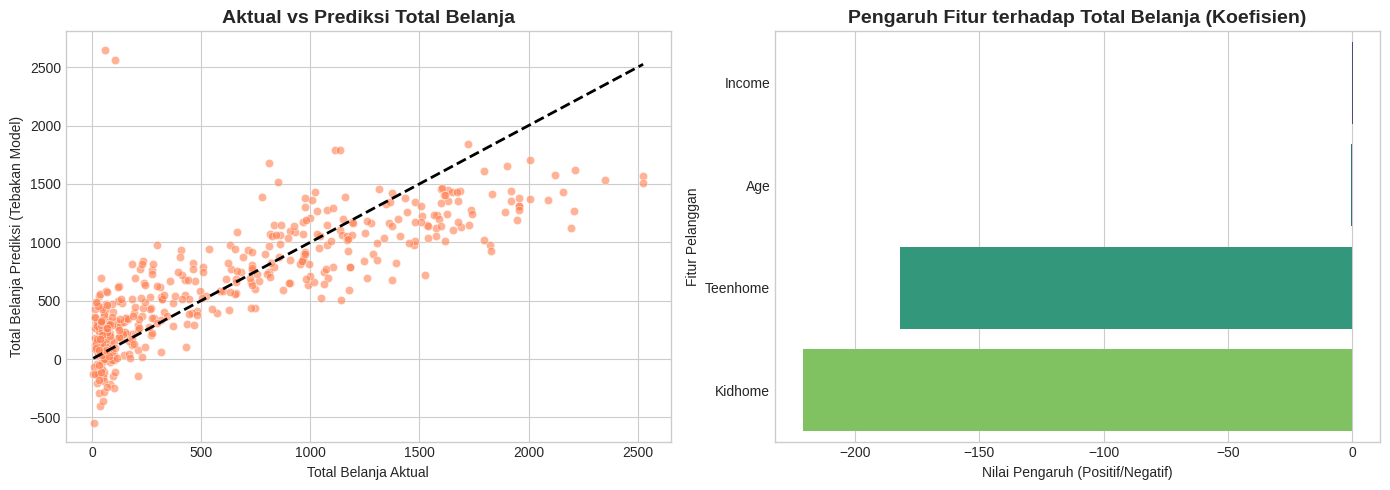


=== Insight Bisnis dari Regresi ===
1. Pada grafik kiri, titik-titik yang mengikuti garis putus-putus hitam menunjukkan bahwa prediksi model sudah cukup baik (semakin dekat ke garis, semakin akurat).
2. Pada grafik kanan, kita bisa melihat bahwa 'Income' (Pendapatan) memberikan dampak positif terhadap pengeluaran, sedangkan memiliki 'Kidhome' (Anak Kecil) secara drastis menurunkan total belanja pelanggan.


In [9]:
# 1. Import library Machine Learning untuk Regresi & Metrik Tambahan
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# 2. Menentukan Fitur (X) dan Target (y)
X_reg = df[['Age', 'Income', 'Kidhome', 'Teenhome']]
y_reg = df['Total_Spend']

# 3. Membagi data: 80% untuk latih (Training) dan 20% untuk uji (Testing)
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 4. Melatih Model Regresi Linear
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# 5. Melakukan Prediksi pada data uji
y_pred = reg_model.predict(X_test)

# 6. Evaluasi Akurasi Model & Metrik Error
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Evaluasi Metrik Model Regresi Linear ===")
print(f"Skor R-squared : {r2:.2f} (Model menjelaskan {round(r2*100)}% pola data)")
print(f"MAE (Rata-rata Error) : {mae:.2f}")
print(f"RMSE (Akar Rata-rata Error): {rmse:.2f}\n")

# =====================================================================
# 7. VISUALISASI HASIL REGRESI UNTUK PORTOFOLIO (UPGRADE)
# =====================================================================
print("Membuat Visualisasi Evaluasi Model...")
plt.figure(figsize=(14, 5))

# Grafik Kiri: Actual vs Predicted (Seberapa tepat tebakan model)
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='coral')
# Membuat garis putus-putus diagonal sebagai representasi tebakan 100% sempurna
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Aktual vs Prediksi Total Belanja', fontsize=14, fontweight='bold')
plt.xlabel('Total Belanja Aktual')
plt.ylabel('Total Belanja Prediksi (Tebakan Model)')

# Grafik Kanan: Kepentingan Fitur / Koefisien (Apa yang bikin belanja naik/turun)
plt.subplot(1, 2, 2)
coef_df = pd.DataFrame({'Fitur': X_reg.columns, 'Koefisien': reg_model.coef_})
coef_df = coef_df.sort_values(by='Koefisien', ascending=False)
sns.barplot(x='Koefisien', y='Fitur', data=coef_df, palette='viridis')
plt.title('Pengaruh Fitur terhadap Total Belanja (Koefisien)', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Pengaruh (Positif/Negatif)')
plt.ylabel('Fitur Pelanggan')

plt.tight_layout()
plt.show()

print("\n=== Insight Bisnis dari Regresi ===")
print("1. Pada grafik kiri, titik-titik yang mengikuti garis putus-putus hitam menunjukkan bahwa prediksi model sudah cukup baik (semakin dekat ke garis, semakin akurat).")
print("2. Pada grafik kanan, kita bisa melihat bahwa 'Income' (Pendapatan) memberikan dampak positif terhadap pengeluaran, sedangkan memiliki 'Kidhome' (Anak Kecil) secara drastis menurunkan total belanja pelanggan.")


=== Menyiapkan Model Klasifikasi (Random Forest) ===

Laporan Klasifikasi (Classification Report):
              precision    recall  f1-score   support

           0       0.86      0.98      0.91       366
           1       0.65      0.22      0.33        77

    accuracy                           0.84       443
   macro avg       0.75      0.60      0.62       443
weighted avg       0.82      0.84      0.81       443


Membuat Visualisasi Evaluasi Model Klasifikasi...


/tmp/ipykernel_1780/3746231745.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Kepentingan', y='Fitur', data=rf_coef, palette='magma')


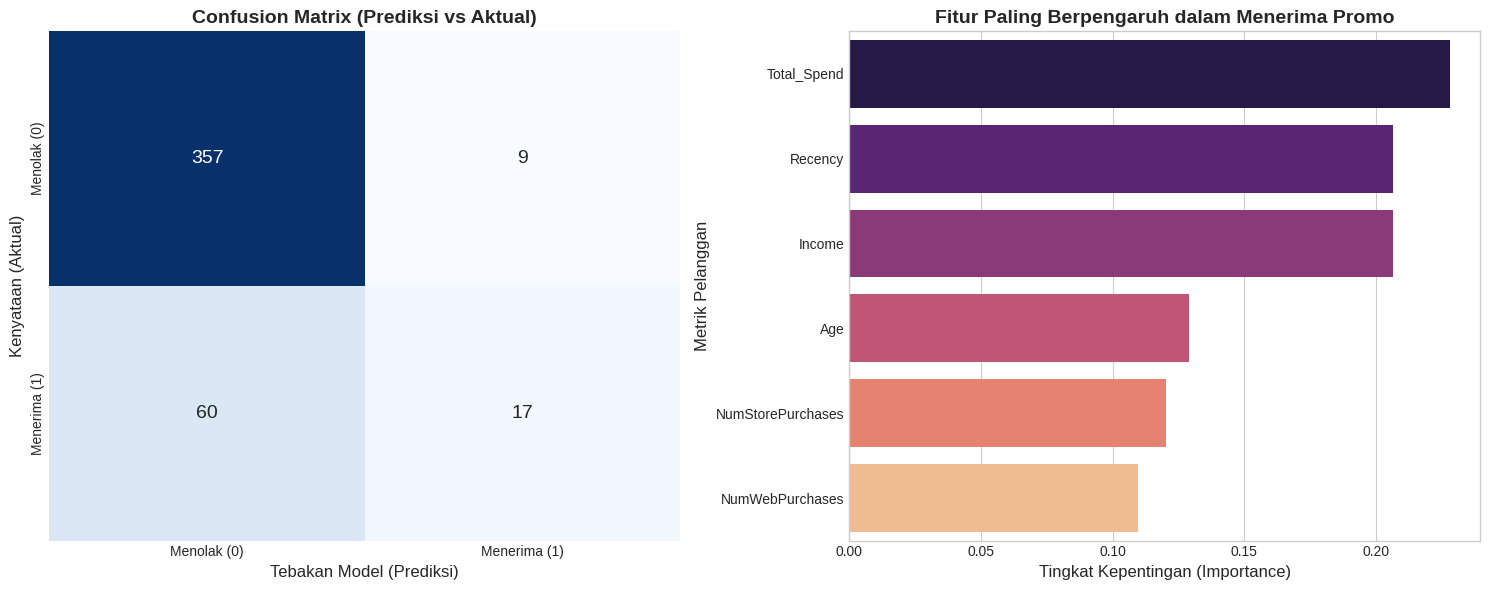


=== Insight Bisnis dari Klasifikasi ===
1. Confusion Matrix: Diagonal kiri atas dan kanan bawah menunjukkan jumlah tebakan model kita yang akurat.
2. Feature Importance: Berdasarkan grafik batang di atas, metrik 'Total_Spend' dan 'Recency' jauh lebih menentukan apakah seseorang akan menerima tawaran promo, dibandingkan dengan preferensi tempat belanja mereka.


In [7]:
# 1. Import library untuk Klasifikasi
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("=== Menyiapkan Model Klasifikasi (Random Forest) ===")

# --- FIX ERROR: Memastikan kolom buatan tersedia ---
# Jika runtime ter-restart, kode ini akan membuat ulang kolom tersebut agar tidak error
if 'Age' not in df.columns:
    df['Age'] = 2026 - df['Year_Birth']

if 'Total_Spend' not in df.columns:
    df['Total_Spend'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + \
                        df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

# Membersihkan data null yang mungkin kembali muncul
df = df.dropna().reset_index(drop=True)
# --------------------------------------------------

# 2. Menentukan Fitur (X) dan Target (y)
X_clf = df[['Age', 'Income', 'Total_Spend', 'Recency', 'NumWebPurchases', 'NumStorePurchases']]
y_clf = df['Response']

# 3. Membagi data (80% Training, 20% Testing)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# 4. Melatih Model Random Forest
# Menggunakan class_weight='balanced' karena mayoritas orang menolak promo (data tidak seimbang)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_c, y_train_c)

# 5. Memprediksi data uji
y_pred_c = rf_model.predict(X_test_c)

# 6. Menampilkan Laporan Evaluasi Teks
print("\nLaporan Klasifikasi (Classification Report):")
print(classification_report(y_test_c, y_pred_c))

# =====================================================================
# 7. VISUALISASI HASIL KLASIFIKASI UNTUK PORTOFOLIO
# =====================================================================
print("\nMembuat Visualisasi Evaluasi Model Klasifikasi...")
plt.figure(figsize=(15, 6))

# Grafik Kiri: Confusion Matrix (Melihat seberapa banyak tebakan yang Benar vs Salah)
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Menolak (0)', 'Menerima (1)'],
            yticklabels=['Menolak (0)', 'Menerima (1)'],
            annot_kws={"size": 14})
plt.title('Confusion Matrix (Prediksi vs Aktual)', fontsize=14, fontweight='bold')
plt.xlabel('Tebakan Model (Prediksi)', fontsize=12)
plt.ylabel('Kenyataan (Aktual)', fontsize=12)

# Grafik Kanan: Feature Importance (Fitur apa yang paling penting untuk prediksi)
plt.subplot(1, 2, 2)
rf_coef = pd.DataFrame({'Fitur': X_clf.columns, 'Kepentingan': rf_model.feature_importances_})
rf_coef = rf_coef.sort_values(by='Kepentingan', ascending=False)
sns.barplot(x='Kepentingan', y='Fitur', data=rf_coef, palette='magma')
plt.title('Fitur Paling Berpengaruh dalam Menerima Promo', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Kepentingan (Importance)', fontsize=12)
plt.ylabel('Metrik Pelanggan', fontsize=12)

plt.tight_layout()
plt.show()

print("\n=== Insight Bisnis dari Klasifikasi ===")
print("1. Confusion Matrix: Diagonal kiri atas dan kanan bawah menunjukkan jumlah tebakan model kita yang akurat.")
print("2. Feature Importance: Berdasarkan grafik batang di atas, metrik 'Total_Spend' dan 'Recency' jauh lebih menentukan apakah seseorang akan menerima tawaran promo, dibandingkan dengan preferensi tempat belanja mereka.")